# IoT Traffic Analysis — Device Type Classification (DL on Packet Windows, RAW vs MASKED)

This notebook extends the **window-based behavioral DL experiment** by adding a **MASKED** variant
and directly comparing **RAW vs MASKED** under a **correct evaluation protocol** (device-level split).

## High-level conclusions (what this experiment shows)

1. **Behavioral learning is possible**
   - When the learning unit is a *packet window* and the split is *by device*, DL no longer trivially memorizes devices.
   - Accuracy drops from ~100% (fingerprinting) to a realistic range, confirming the task is now harder and meaningful.

2. **RAW vs MASKED is now a valid comparison**
   - Any performance difference reflects reliance on header-level information (MAC/IP/ports).
   - This comparison was *not meaningful* in the earlier fingerprinting notebooks.

3. **Residual accuracy means residual behavior**
   - Remaining accuracy after masking indicates that device types differ in traffic shape,
     burstiness, and packet structure — not just identity fields.

This notebook contains **only DL experiments** (no ML yet).


In [1]:
# 1) Imports & configuration
import os, glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from scapy.all import PcapReader, Ether, IP, TCP, UDP

RANDOM_STATE = 43
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PCAP_DATA_GLOB = "unsw-dataset/pcaps/*.pcap"

MAX_LEN = 500
PKTS_PER_WINDOW = 50
STRIDE = 50
MAX_WINDOWS_PER_DEVICE = 1500

BATCH_SIZE = 128
EPOCHS = 5
SHUFFLE_BUF = 5000


2026-01-13 17:31:26.994044: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 17:31:27.066477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 17:31:29.209198: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2) Device → Type mapping

In [2]:
device_to_type = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

pcap_files = sorted(glob.glob(PCAP_DATA_GLOB))
rows = []
for fp in pcap_files:
    dev = os.path.basename(fp).replace(".pcap", "")
    if dev in device_to_type:
        rows.append({"device": dev, "device_type": device_to_type[dev], "pcap_path": fp})

df_pcaps = pd.DataFrame(rows)
display(df_pcaps["device_type"].value_counts())


device_type
camera_streamer          8
sensor_meter             6
media_speaker_display    5
actuator_light_plug      4
hub_gateway_bridge       2
Name: count, dtype: int64

## 3) Device-level train/test split

In [3]:
devices = df_pcaps["device"].tolist()
types = df_pcaps["device_type"].tolist()

train_devs, test_devs = train_test_split(
    devices, test_size=0.30, random_state=RANDOM_STATE, stratify=types
)

df_train = df_pcaps[df_pcaps["device"].isin(train_devs)]
df_test  = df_pcaps[df_pcaps["device"].isin(test_devs)]

type_classes = sorted(df_pcaps["device_type"].unique())
type_to_idx = {t:i for i,t in enumerate(type_classes)}
idx_to_type = {i:t for t,i in type_to_idx.items()}


## 4) Packet → bytes (RAW and MASKED)

In [4]:
def packet_to_bytes(pkt, masked=False):
    try:
        p = pkt
        if masked:
            if p.haslayer(Ether):
                p = p.payload
            if p.haslayer(IP):
                p[IP].src = "0.0.0.0"
                p[IP].dst = "0.0.0.0"
                if hasattr(p[IP], "chksum"):
                    del p[IP].chksum
            if p.haslayer(TCP):
                p[TCP].sport = 0
                p[TCP].dport = 0
                if hasattr(p[TCP], "chksum"):
                    del p[TCP].chksum
            if p.haslayer(UDP):
                p[UDP].sport = 0
                p[UDP].dport = 0
                if hasattr(p[UDP], "chksum"):
                    del p[UDP].chksum

        arr = np.frombuffer(bytes(p), dtype=np.uint8)
        if len(arr) >= MAX_LEN:
            return arr[:MAX_LEN]
        return np.pad(arr, (0, MAX_LEN - len(arr)))
    except Exception:
        return None


## 5) Window generator

In [5]:
def iter_windows(df_subset, masked=False):
    order = df_subset.sample(frac=1.0, random_state=RANDOM_STATE)
    for _, row in order.iterrows():
        y = type_to_idx[row["device_type"]]
        buf, produced = [], 0
        with PcapReader(row["pcap_path"]) as pcap:
            for pkt in pcap:
                arr = packet_to_bytes(pkt, masked)
                if arr is None:
                    continue
                buf.append(arr)
                if len(buf) == PKTS_PER_WINDOW:
                    yield np.stack(buf).astype(np.float32)/255.0, np.int64(y)
                    produced += 1
                    if produced >= MAX_WINDOWS_PER_DEVICE:
                        break
                    buf = [] if STRIDE >= PKTS_PER_WINDOW else buf[STRIDE:]


## 6) tf.data datasets

In [6]:
def make_dataset(df_subset, masked=False, repeat=False, shuffle_buf=5000):
    output_signature = (
        tf.TensorSpec(shape=(PKTS_PER_WINDOW, MAX_LEN), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64),
    )
    ds = tf.data.Dataset.from_generator(
        lambda: iter_windows(df_subset, masked),
        output_signature=output_signature
    )
    if shuffle_buf:
        ds = ds.shuffle(shuffle_buf, seed=RANDOM_STATE)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(lambda x,y:(tf.expand_dims(x,-1),y))
    return ds.batch(BATCH_SIZE).prefetch(1)

ds_train_raw  = make_dataset(df_train, masked=False, repeat=True)
ds_test_raw   = make_dataset(df_test,  masked=False, repeat=False, shuffle_buf=0)
ds_train_mask = make_dataset(df_train, masked=True,  repeat=True)
ds_test_mask  = make_dataset(df_test,  masked=True,  repeat=False, shuffle_buf=0)

steps_per_epoch = min(500, int(np.ceil(len(df_train)*MAX_WINDOWS_PER_DEVICE/BATCH_SIZE)))


2026-01-13 17:31:30.557395: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 7) DL model

In [7]:
def make_model():
    m = Sequential([
        Input(shape=(PKTS_PER_WINDOW, MAX_LEN, 1)),
        Conv2D(16,(3,7),activation="relu"),
        MaxPooling2D((2,2)),
        Conv2D(32,(3,7),activation="relu"),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128,activation="relu"),
        Dropout(0.3),
        Dense(len(type_classes),activation="softmax")
    ])
    m.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    return m


## 8) Train & evaluate — RAW vs MASKED

In [8]:
tf.keras.backend.clear_session()
model_raw = make_model()
hist_raw = model_raw.fit(ds_train_raw, epochs=EPOCHS, steps_per_epoch=steps_per_epoch)
raw_loss, raw_acc = model_raw.evaluate(ds_test_raw, verbose=0)

tf.keras.backend.clear_session()
model_mask = make_model()
hist_mask = model_mask.fit(ds_train_mask, epochs=EPOCHS, steps_per_epoch=steps_per_epoch)
mask_loss, mask_acc = model_mask.evaluate(ds_test_mask, verbose=0)

print("DL RAW accuracy:", raw_acc)
print("DL MASKED accuracy:", mask_acc)


Epoch 1/5


2026-01-13 17:31:42.463774: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 442 of 5000
2026-01-13 17:31:52.466809: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 897 of 5000
2026-01-13 17:32:12.479934: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 1900 of 5000
2026-01-13 17:32:32.477716: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 2955 of 5000
2026-01-13 17:32:52.471830: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:2,RepeatDataset:3): Filling up shuffle buffer (this may take a while): 4035 of 5000
2026-01-13 17:33:10.833534: I tensorf

200/200 ━━━━━━━━━━━━━━━━━━━━ 739s 3s/step - accuracy: 0.8995 - loss: 0.3332
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 598s 3s/step - accuracy: 0.9895 - loss: 0.0372
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 703s 4s/step - accuracy: 0.9968 - loss: 0.0121
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.9991 - loss: 0.0042
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 596s 3s/step - accuracy: 0.9992 - loss: 0.0032


2026-01-13 18:29:10.413462: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/5


2026-01-13 18:29:21.710093: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:14,RepeatDataset:15): Filling up shuffle buffer (this may take a while): 295 of 5000
2026-01-13 18:29:31.712534: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:14,RepeatDataset:15): Filling up shuffle buffer (this may take a while): 589 of 5000
2026-01-13 18:29:51.708146: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:14,RepeatDataset:15): Filling up shuffle buffer (this may take a while): 1172 of 5000
2026-01-13 18:30:11.717032: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:14,RepeatDataset:15): Filling up shuffle buffer (this may take a while): 1784 of 5000
2026-01-13 18:30:21.717671: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] fused(ShuffleDatasetV3:14,RepeatDataset:15): Filling up shuffle buffer (this may take a while): 2050 of 5000
2026-01-13 18:30:41.713521:

200/200 ━━━━━━━━━━━━━━━━━━━━ 1286s 6s/step - accuracy: 0.9202 - loss: 0.2777
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1442s 7s/step - accuracy: 0.9870 - loss: 0.0425
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 2375s 12s/step - accuracy: 0.9946 - loss: 0.0179
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1909s 10s/step - accuracy: 0.9971 - loss: 0.0096
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1225s 6s/step - accuracy: 0.9980 - loss: 0.0072
DL RAW accuracy: 0.3158127963542938
DL MASKED accuracy: 0.33212196826934814


2026-01-13 20:53:56.333794: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


## 9) Comparison

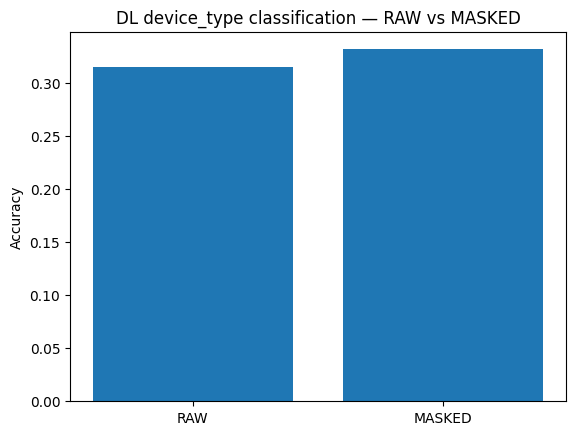

In [9]:
plt.bar(["RAW","MASKED"], [raw_acc, mask_acc])
plt.ylabel("Accuracy")
plt.title("DL device_type classification — RAW vs MASKED")
plt.show()
